In [5]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Advertising.csv")

In [8]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


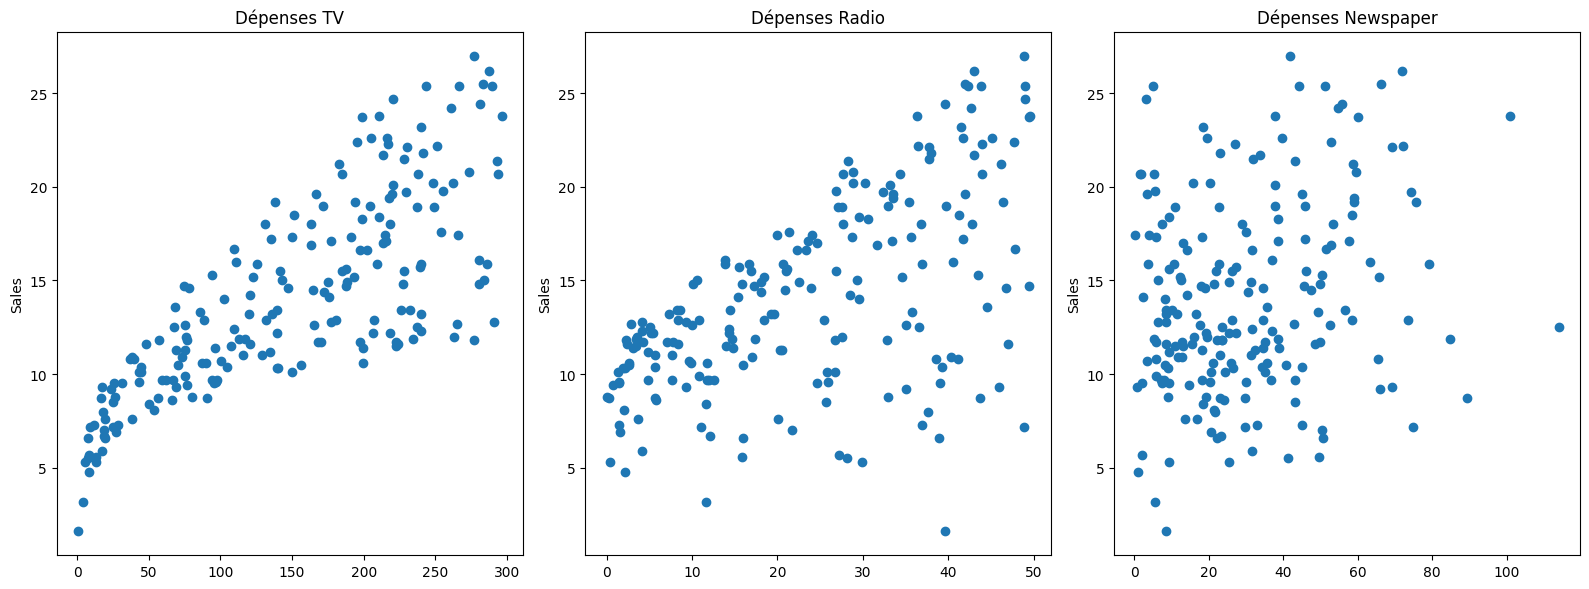

In [9]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("Dépenses TV")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_title("Dépenses Radio")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_title("Dépenses Newspaper");
axes[2].set_ylabel("Sales")
plt.tight_layout();

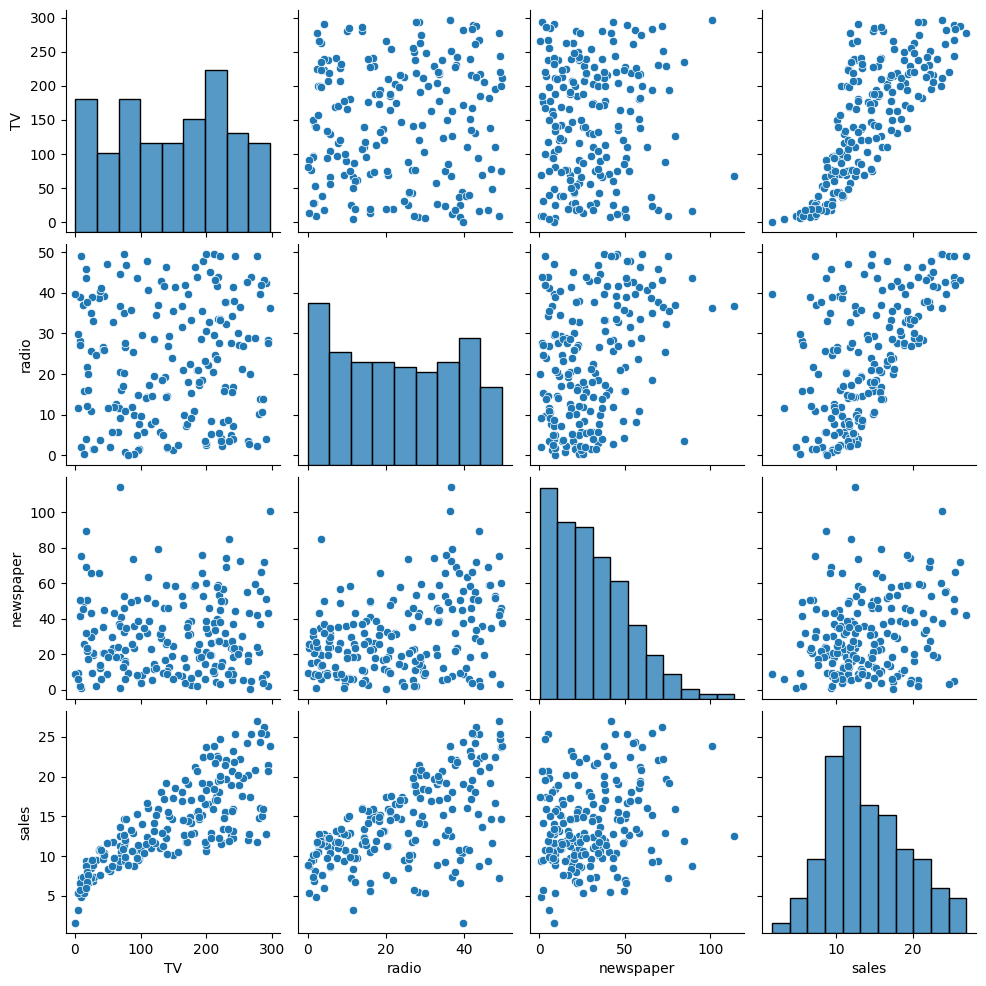

In [10]:
sns.pairplot(df)

In [11]:
X = df.drop(columns=["sales"])

In [12]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [13]:
y = df["sales"]

In [14]:
y

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [17]:
len(df)

200

In [18]:
X_train

,TV,radio,newspaper
85,193.2,18.4,65.7
183,287.6,43.0,71.8
127,80.2,0.0,9.2
53,182.6,46.2,58.7
100,222.4,4.3,49.8
...,...,...,...
63,102.7,29.6,8.4
70,199.1,30.6,38.7
81,239.8,4.1,36.9
11,214.7,24.0,4.0


In [19]:
y_train

,sales
85,15.2
183,26.2
127,8.8
53,21.2
100,11.7
...,...
63,14.0
70,18.3
81,12.3
11,17.4


In [20]:
len(X_test)

60

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

LinearRegression()

In [27]:
test_predictions = model.predict(X_test)

In [28]:
test_predictions

array([15.74131332, 19.61062568, 11.44888935, 17.00819787,  9.17285676,
        7.01248287, 20.28992463, 17.29953992,  9.77584467, 19.22194224,
       12.40503154, 13.89234998, 13.72541098, 21.28794031, 18.42456638,
        9.98198406, 15.55228966,  7.68913693,  7.55614992, 20.40311209,
        7.79215204, 18.24214098, 24.68631904, 22.82199068,  7.97962085,
       12.65207264, 21.46925937,  8.05228573, 12.42315981, 12.50719678,
       10.77757812, 19.24460093, 10.070269  ,  6.70779999, 17.31492147,
        7.76764327,  9.25393336,  8.27834697, 10.58105585, 10.63591128,
       13.01002595,  9.77192057, 10.21469861,  8.04572042, 11.5671075 ,
       10.08368001,  8.99806574, 16.25388914, 13.23942315, 20.81493419,
       12.49727439, 13.96615898, 17.56285075, 11.14537013, 12.56261468,
        5.50870279, 23.29465134, 12.62409688, 18.77399978, 15.18785675])

In [25]:
X_test.head()

,TV,radio,newspaper
37,74.7,49.4,45.7
109,255.4,26.9,5.5
31,112.9,17.4,38.6
89,109.8,47.8,51.4
66,31.5,24.6,2.2


In [26]:
y_test

,sales
37,14.7
109,19.8
31,11.9
89,16.7
66,9.5
119,6.6
54,20.2
74,17.0
145,10.3
142,20.1


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
df["sales"].mean()

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

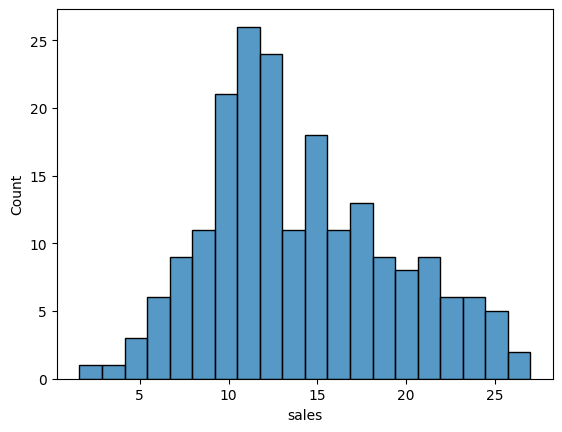

In [32]:
sns.histplot(data=df, x = "sales", bins=20)

In [33]:
mean_absolute_error(y_test,test_predictions)

1.213745773614481

In [35]:
#RMSE
np.sqrt(mean_squared_error(y_test, test_predictions))

np.float64(1.5161519375993884)

In [38]:
test_residuals = y_test - test_predictions

In [39]:
test_residuals

,sales
37,-1.041313
109,0.189374
31,0.451111
89,-0.308198
66,0.327143
119,-0.412483
54,-0.089925
74,-0.299540
145,0.524155
142,0.878058


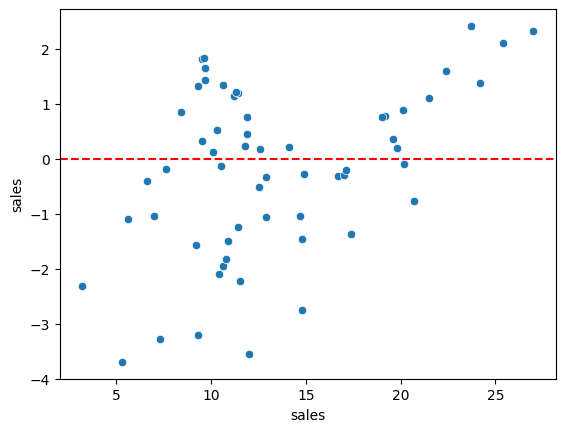

In [41]:
sns.scatterplot(x=y_test, y=test_residuals)
plt.axhline(y=0, color="red", ls="--")

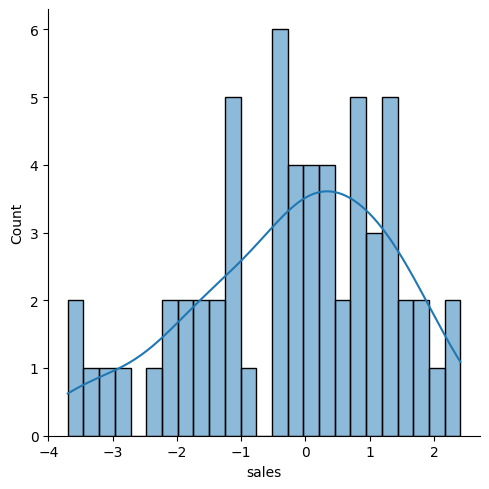

In [42]:
sns.displot(test_residuals, bins=25, kde=True)

In [43]:
import scipy as sp

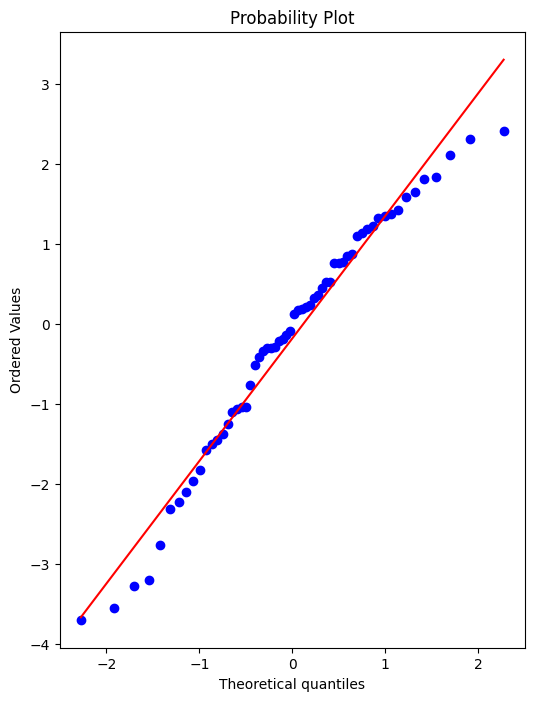

In [44]:
fig, ax = plt.subplots(figsize=(6,8),dpi=100)

_ = sp.stats.probplot(test_residuals,plot=ax)

In [45]:
final_model = LinearRegression()

In [46]:
final_model.fit(X,y)

LinearRegression()

In [47]:
final_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [48]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [49]:
y_hat = final_model.predict(X)

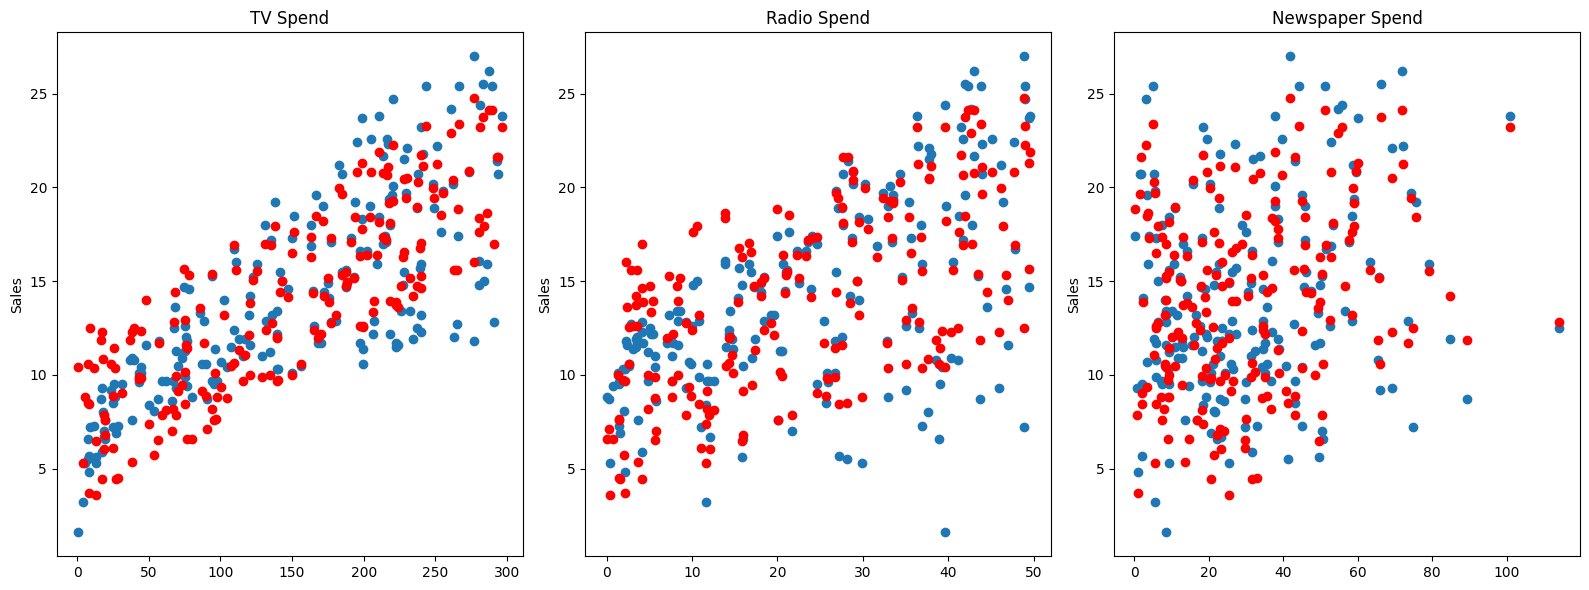

In [51]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o',color='red')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o',color='red')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'o',color='red')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout();

In [52]:
from joblib import dump, load

In [53]:
dump(final_model, "final_sales_model.joblib")

['final_sales_model.joblib']

In [54]:
loaded_model = load("final_sales_model.joblib")

In [55]:
loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

In [56]:
X.shape

(200, 3)

In [59]:
# 149 TV, 22 radio, 12 Newspaper
# Sales
ads_values = [[149,22,12]]
X_cols = X.columns
campaign = pd.DataFrame(data=ads_values, columns=X_cols)
campaign

,TV,radio,newspaper
0,149,22,12


In [61]:
loaded_model.predict(campaign)

array([13.893032])